
<div dir=ltr align=center>

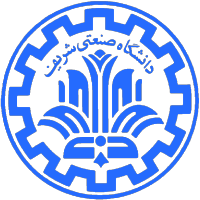

<br>
<font>
<div dir=ltr align=center>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Arash Marioriyad<br>
    Spring 2026<br>
<font color=3C99D size=5>
    Practical HomeWork 5<br>
    Q-Learning and SARSA<br>
<font color=696880 size=4>
    Reza Eslami Abyane

____

`Full Name:`محمد مهدی مرادی

`Student ID:`403106681


## Project Description

In this homework, we implement and compare two classical reinforcement learning algorithms:

1. **Q-Learning**
2. **SARSA**

We evaluate these algorithms on the **Taxi-v3** environment from the Gymnasium library.

Additionally, we compare two different action-selection strategies:

- **Fixed Epsilon-Greedy**
- **Decaying Epsilon-Greedy**

---

## Objective of Taxi

The goal of the Taxi problem is to pick up a passenger at one location and drop them off at their destination in the shortest time possible. The agent must navigate a 5×5 grid, avoid illegal pickups and dropoffs, and plan an efficient route.

## Algorithms Overview

### Q-Learning

Q-Learning is an **off-policy** temporal difference learning algorithm.
It updates the Q-values using the maximum estimated future reward.

Update equation:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max_{a'} Q(s',a') - Q(s,a)]
$$

---

### SARSA

SARSA is an **on-policy** temporal difference learning algorithm.
It updates the Q-values using the action actually selected by the current policy.

Update equation:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma Q(s',a') - Q(s,a)]
$$

---

## Exploration Strategies

### Fixed Epsilon-Greedy

- With probability $\epsilon$, choose a random action.
- Otherwise, choose the best known action.

### Decaying Epsilon-Greedy

- Start with a high exploration rate.
- Gradually reduce epsilon during training.
- Helps the agent explore early and exploit later.

---

## Goals of This Homework

- Implement Q-Learning
- Implement SARSA
- Implement epsilon-greedy exploration
- Implement decaying epsilon-greedy exploration
- Train agents on Taxi-v3
- Compare learning performance using plots and evaluation metrics

In [1]:
import math
import random
from dataclasses import dataclass

import gymnasium as gym
import matplotlib.pyplot as plt
import time
import numpy as np
import pandas as pd
from tqdm.auto import trange

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

SEED = 42

## Environment Overview

Taxi-v3 has:
- observation space: 500 discrete states (no discretization needed)
- action space: 6 discrete actions (south, north, east, west, pickup, dropoff)
- reward: -1 per step, +20 for successful dropoff, -10 for illegal pickup/dropoff
- episode limit: 200 steps


In [2]:
env = gym.make('Taxi-v3')

print(f"State space: {env.observation_space.n}")
print(f"Action space: {env.action_space.n}")  
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
obs, info = env.reset()
print("Initial observation:", obs)
env.close()

State space: 500
Action space: 6
Observation space: Discrete(500)
Action space: Discrete(6)
Initial observation: 214


## Action selection

Two action-selection rules are used:

- **epsilon-greedy**: explore with a fixed probability `epsilon`
- **decaying epsilon-greedy**: start exploratory, then reduce `epsilon` over episodes

In [3]:
def epsilon_greedy_action(q_table, state, epsilon, n_actions, rng):
    # TODO: Implement epsilon-greedy action selection
    # Choose a random action with probability epsilon
    # Otherwise choose the best action
    if rng.random() < epsilon:
        return int(rng.integers(n_actions))
    else:
        return int(np.argmax(q_table[state]))


def epsilon_schedule_fixed(episode, epsilon_start=0.1, epsilon_min=0.1, decay_rate=1.0):
    # TODO: Implement fixed epsilon schedule
    # Return a constant epsilon value throughout training
    return epsilon_start


def epsilon_schedule_decay(episode, epsilon_start=1.0, epsilon_min=0.01, decay_rate=0.995):
    # TODO: Implement decaying epsilon schedule
    # Return epsilon that decays exponentially: epsilon_start * (decay_rate ^ episode)
    # Make sure epsilon never goes below epsilon_min
    return max(epsilon_min, epsilon_start * (decay_rate ** episode))

## Training functions

The notebook trains four combinations:

1. Q-learning + fixed epsilon-greedy
2. Q-learning + decaying epsilon-greedy
3. SARSA + fixed epsilon-greedy
4. SARSA + decaying epsilon-greedy

For each run, it records episode return and episode length, then evaluates the learned policy without exploration.  
Q-learning is off-policy and updates toward the greedy next action. SARSA is on-policy and updates using the next action actually chosen by the behavior policy.

In [4]:
@dataclass
class TrainResult:
    q_table: np.ndarray
    episode_returns: np.ndarray
    episode_lengths: np.ndarray
    epsilons: np.ndarray

def train_q_learning(
    env_id="Taxi-v3",
    episodes=5000,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.01,
    decay_rate=0.995,
    schedule="decay",
):
    env = gym.make(env_id)
    rng = np.random.default_rng()
    
    # TODO: Initialize Q-table with correct shape
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    
    # TODO: Initialize arrays to store episode returns, lengths, and epsilons
    episode_returns = np.zeros(episodes)
    episode_lengths = np.zeros(episodes)
    epsilons = np.zeros(episodes)

    for ep in trange(episodes, desc=f"Q-learning ({schedule})"):
        # TODO: Reset environment and get initial state
        state, _ = env.reset()
        
        # TODO: Choose epsilon based on schedule
        if schedule == "fixed":
            epsilon = epsilon_schedule_fixed(ep, epsilon_start, epsilon_min, decay_rate)
        else:
            epsilon = epsilon_schedule_decay(ep, epsilon_start, epsilon_min, decay_rate)
        epsilons[ep] = epsilon

        done = False
        total_reward = 0.0
        t = 0

        while not done:
            # TODO: Select action using epsilon-greedy
            action = epsilon_greedy_action(q_table, state, epsilon, env.action_space.n, rng)
            
            # TODO: Take action in environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            
            # TODO: Check if episode is done
            done = terminated or truncated
            
            # TODO: Compute Q-learning target
            if terminated:
                target = reward
            else:
                target = reward + gamma * np.max(q_table[next_state])
            
            # TODO: Update Q-value
            q_table[state][action] += alpha * (target - q_table[state][action])

            state = next_state
            total_reward += reward
            t += 1

        episode_returns[ep] = total_reward
        episode_lengths[ep] = t

    env.close()
    return TrainResult(q_table, episode_returns, episode_lengths, epsilons)


def train_sarsa(
    env_id="Taxi-v3",
    episodes=5000,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.01,
    decay_rate=0.995,
    schedule="decay",
):
    env = gym.make(env_id)
    rng = np.random.default_rng()
    
    # TODO: Initialize Q-table with correct shape
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    
    # TODO: Initialize arrays to store episode returns, lengths, and epsilons
    episode_returns = np.zeros(episodes)
    episode_lengths = np.zeros(episodes)
    epsilons = np.zeros(episodes)

    for ep in trange(episodes, desc=f"SARSA ({schedule})"):
        # TODO: Reset environment and get initial state
        state, _ = env.reset()
        
        # TODO: Choose epsilon based on schedule
        if schedule == "fixed":
            epsilon = epsilon_schedule_fixed(ep, epsilon_start, epsilon_min, decay_rate)
        else:
            epsilon = epsilon_schedule_decay(ep, epsilon_start, epsilon_min, decay_rate)
        epsilons[ep] = epsilon

        # TODO: Select initial action using epsilon-greedy
        action = epsilon_greedy_action(q_table, state, epsilon, env.action_space.n, rng)
        
        done = False
        total_reward = 0.0
        t = 0

        while not done:
            # TODO: Take action in environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            
            # TODO: Select next action using epsilon-greedy
            next_action = epsilon_greedy_action(q_table, next_state, epsilon, env.action_space.n, rng)
            
            # TODO: Check if episode is done
            done = terminated or truncated
            
            # TODO: Compute SARSA target
            if terminated:
                target = reward
            else:
                target = reward + gamma * q_table[next_state][next_action]
            
            # TODO: Update Q-value
            q_table[state][action] += alpha * (target - q_table[state][action])

            state = next_state
            action = next_action
            total_reward += reward
            t += 1

        episode_returns[ep] = total_reward
        episode_lengths[ep] = t

    env.close()
    return TrainResult(q_table, episode_returns, episode_lengths, epsilons)

## Evaluation

Evaluation uses a greedy policy (`epsilon = 0`) to measure how well the learned Q-table performs after training.

In [5]:
def evaluate_policy(q_table, episodes=20, seed=SEED, env_id="Taxi-v3"):
    env = gym.make(env_id)
    
    returns = []
    lengths = []
    successes = 0

    for ep in range(episodes):
        state, _ = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0
        t = 0

        while not done:
            # TODO: Select greedy action (no exploration)
            action = int(np.argmax(q_table[state]))
            
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            t += 1
            done = terminated or truncated
            
            # TODO: Check if episode was successful
            if reward == 20:
                successes += 1

        returns.append(total_reward)
        lengths.append(t)

    env.close()
    return {
        "avg_return": float(np.mean(returns)),
        "avg_length": float(np.mean(lengths)),
        "success_rate": float(successes / episodes),
        "returns": np.array(returns),
        "lengths": np.array(lengths),
    }

## Run the experiments

We run the training for different numbers of episodes: 500, 1000, 3000, and 5000. For each episode count, we train four agents combining algorithm (Q-Learning, SARSA) and action selection policy (Fixed ε-greedy, Decaying ε-greedy).

In [6]:
ALPHA = 0.1
GAMMA = 0.99
EPISODES_LIST = [500, 1000, 3000, 5000]

def train_agent(episodes):
    print(f"\nTraining with {episodes} episodes...")
    results = {}
    
    results["q_fixed"] = train_q_learning(
        episodes=episodes,
        alpha=ALPHA,
        gamma=GAMMA,
        epsilon_start=0.1,
        epsilon_min=0.1,
        decay_rate=1.0,
        schedule="fixed",
    )

    results["q_decay"] = train_q_learning(
        episodes=episodes,
        alpha=ALPHA,
        gamma=GAMMA,
        epsilon_start=1.0,
        epsilon_min=0.01,
        decay_rate=0.995,
        schedule="decay",
    )

    results["sarsa_fixed"] = train_sarsa(
        episodes=episodes,
        alpha=ALPHA,
        gamma=GAMMA,
        epsilon_start=0.1,
        epsilon_min=0.1,
        decay_rate=1.0,
        schedule="fixed",
    )

    results["sarsa_decay"] = train_sarsa(
        episodes=episodes,
        alpha=ALPHA,
        gamma=GAMMA,
        epsilon_start=1.0,
        epsilon_min=0.01,
        decay_rate=0.995,
        schedule="decay",
    )
    
    return results

# Train for each episode count and save results
results_500 = train_agent(500)
results_1000 = train_agent(1000)
results_3000 = train_agent(3000)
results_5000 = train_agent(5000)

print("All agents trained and saved!")


Training with 500 episodes...


Q-learning (fixed):   0%|          | 0/500 [00:00<?, ?it/s]

Q-learning (decay):   0%|          | 0/500 [00:00<?, ?it/s]

SARSA (fixed):   0%|          | 0/500 [00:00<?, ?it/s]

SARSA (decay):   0%|          | 0/500 [00:00<?, ?it/s]

...

Q-learning (fixed):   0%|          | 0/5000 [00:00<?, ?it/s]

Q-learning (decay):   0%|          | 0/5000 [00:00<?, ?it/s]

SARSA (fixed):   0%|          | 0/5000 [00:00<?, ?it/s]

SARSA (decay):   0%|          | 0/5000 [00:00<?, ?it/s]

All agents trained and saved!


## Performance Summary

Tables showing evaluation metrics for each agent at different training episode counts, followed by a combined summary of all results.

In [7]:
all_eval_rows = []

all_results = {
    "500": results_500,
    "1000": results_1000,
    "3000": results_3000,
    "5000": results_5000,
}

for episodes, results in all_results.items():
    eval_rows = []
    
    for name, res in results.items():
        metrics = evaluate_policy(res.q_table, episodes=20)
        eval_rows.append({
            "algorithm": name,
            "avg_eval_return": metrics["avg_return"],
            "avg_eval_length": metrics["avg_length"],
            "success_rate": metrics["success_rate"],
        })
        
        all_eval_rows.append({
            "episodes": episodes,
            "algorithm": name,
            "avg_eval_return": metrics["avg_return"],
            "avg_eval_length": metrics["avg_length"],
            "success_rate": metrics["success_rate"],
        })
    
    print(f"\n{'='*50}")
    print(f"Episodes: {episodes}")
    print(f"{'='*50}")
    summary_ep = pd.DataFrame(eval_rows).sort_values("avg_eval_return", ascending=False).reset_index(drop=True)
    print(summary_ep)

print(f"\n{'='*50}")
print("ALL RESULTS")
print(f"{'='*50}")
summary_df = pd.DataFrame(all_eval_rows).sort_values("avg_eval_return", ascending=False).reset_index(drop=True)
summary_df


Episodes: 500
     algorithm  avg_eval_return  avg_eval_length  success_rate
0      q_decay           -189.4           190.45          0.05
1  sarsa_fixed           -189.4           190.45          0.05
2  sarsa_decay           -200.0           200.00          0.00
3      q_fixed           -290.0           200.00          0.00

Episodes: 1000
     algorithm  avg_eval_return  avg_eval_length  success_rate
0      q_fixed          -147.50           152.75          0.25
1  sarsa_decay          -168.40           171.55          0.15
2      q_decay          -168.45           171.60          0.15
3  sarsa_fixed          -168.45           171.60          0.15

Episodes: 3000
     algorithm  avg_eval_return  avg_eval_length  success_rate
0      q_fixed             6.85            14.15          1.00
1      q_decay             6.85            14.15          1.00
2  sarsa_fixed            -3.40            23.35          0.95
3  sarsa_decay           -13.55            32.45          0.90

Episode

,episodes,algorithm,avg_eval_return,avg_eval_length,success_rate
0,3000,q_fixed,6.85,14.15,1.00
1,3000,q_decay,6.85,14.15,1.00
2,5000,q_fixed,6.85,14.15,1.00
3,5000,q_decay,6.85,14.15,1.00
4,5000,sarsa_fixed,6.85,14.15,1.00
5,5000,sarsa_decay,6.85,14.15,1.00
6,3000,sarsa_fixed,-3.40,23.35,0.95
7,3000,sarsa_decay,-13.55,32.45,0.90
8,1000,q_fixed,-147.50,152.75,0.25
9,1000,sarsa_decay,-168.40,171.55,0.15


## Training Curves

The plots below show the moving average of episode returns and lengths during training for each combination of algorithm and policy. Each plot corresponds to a different number of training episodes (500, 1000, 3000, 5000).

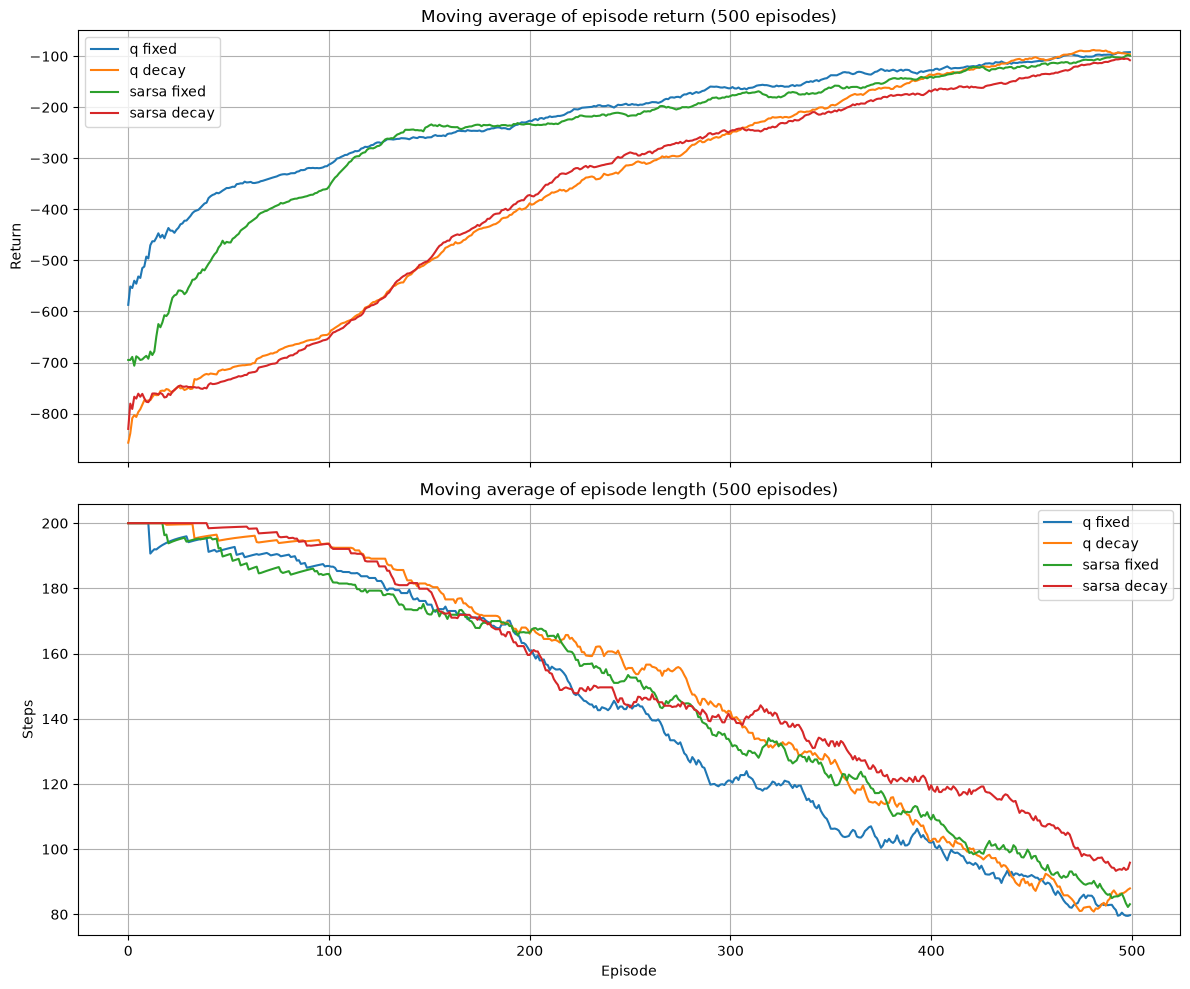

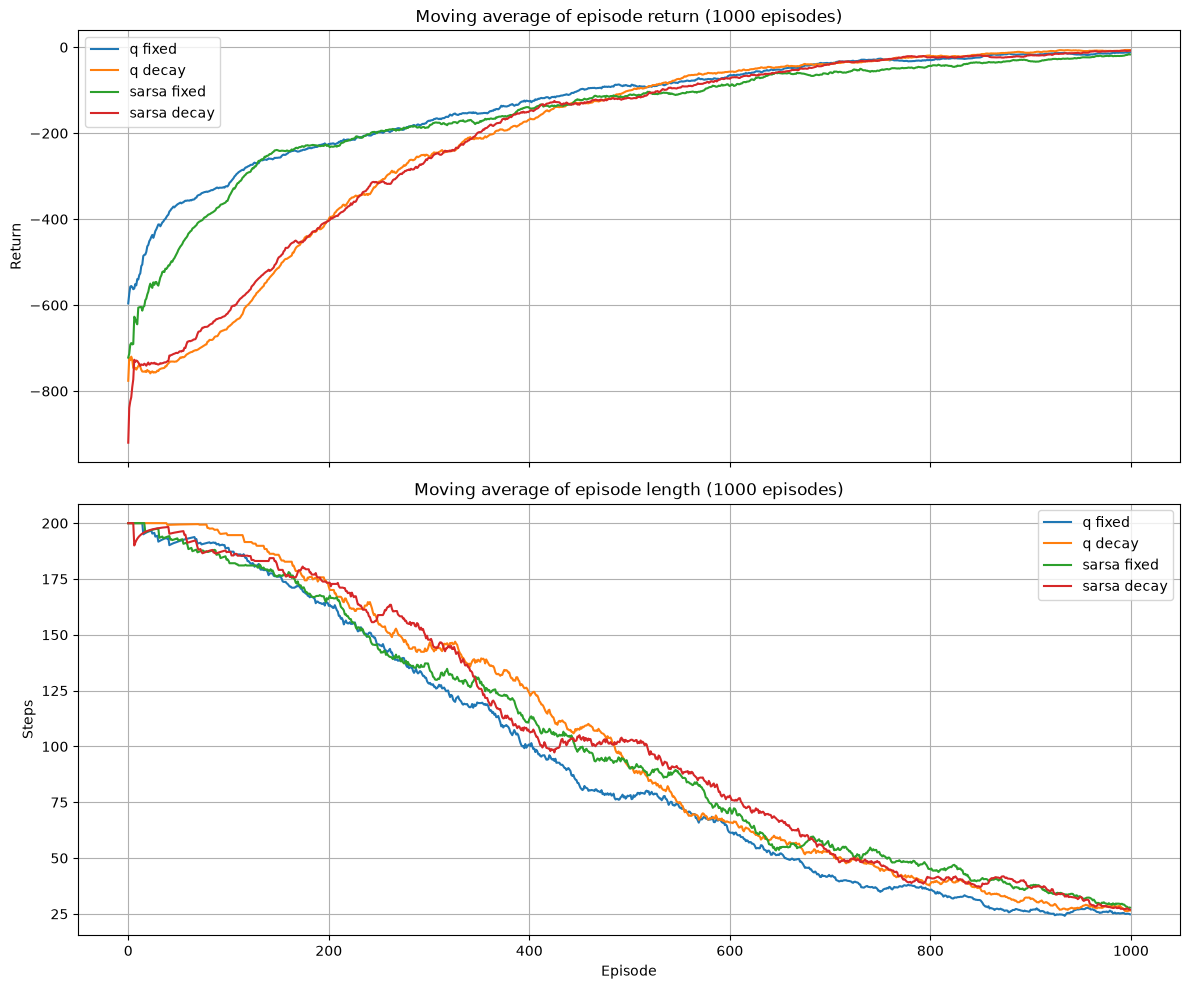

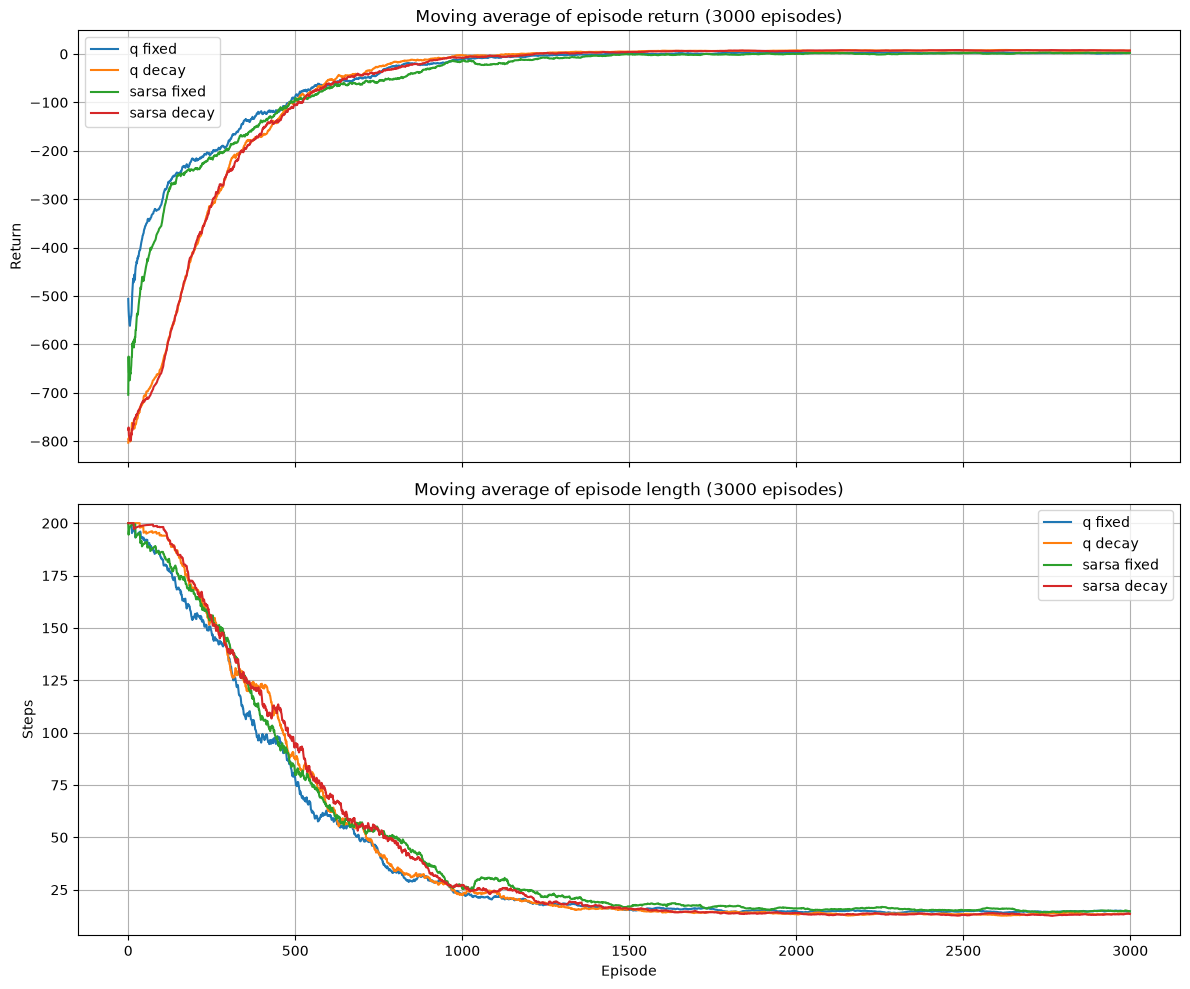

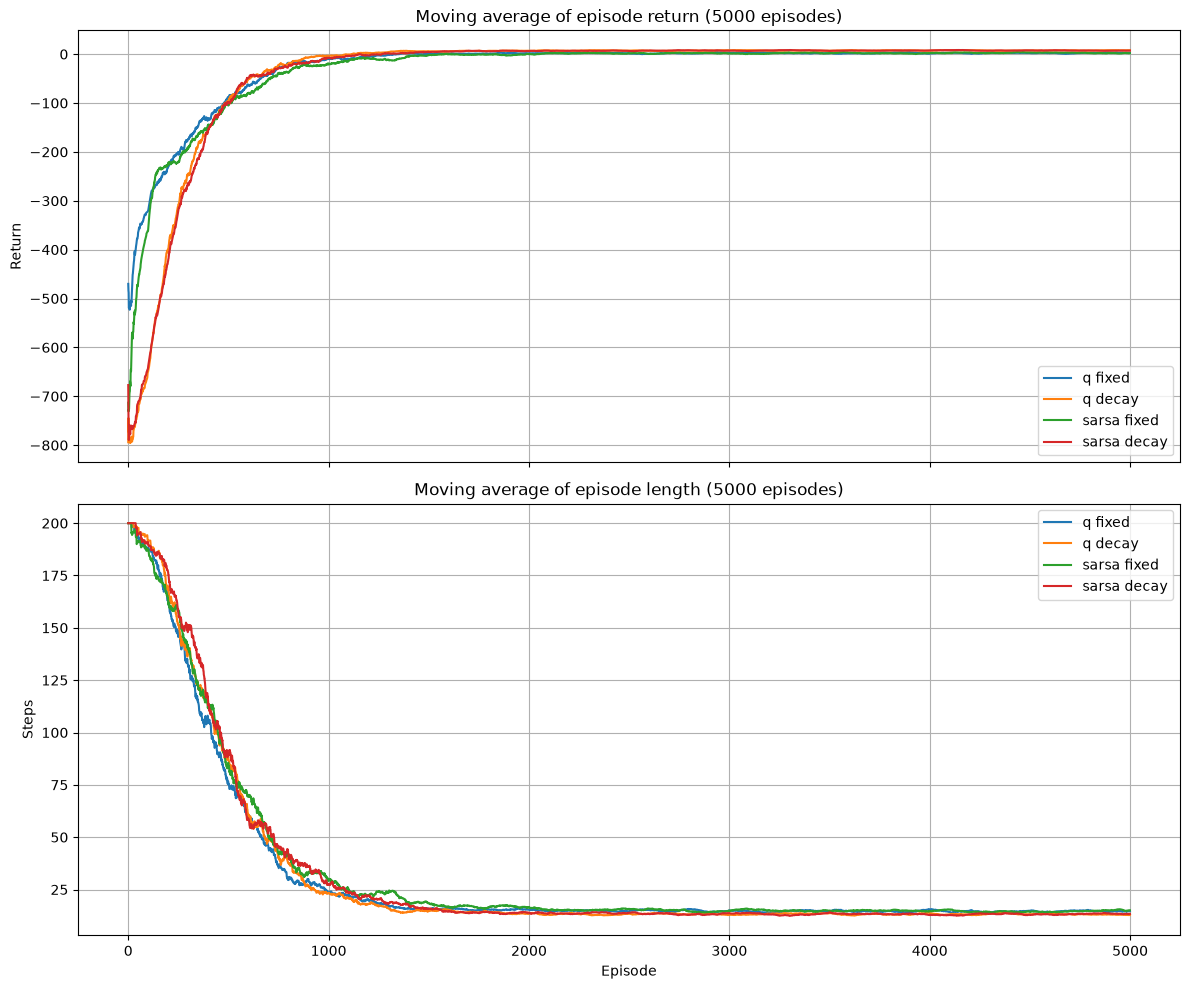

In [8]:
def moving_average(x, window=100):
    if len(x) < window:
        return np.array([])
    return pd.Series(x).rolling(window=window, min_periods=1).mean().values

for episodes, results in all_results.items():
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    for name, res in results.items():
        label = name.replace("_", " ")
        axes[0].plot(moving_average(res.episode_returns, 100), label=label)
        axes[1].plot(moving_average(res.episode_lengths, 100), label=label)
    
    axes[0].set_title(f"Moving average of episode return ({episodes} episodes)")
    axes[0].set_ylabel("Return")
    axes[0].legend()
    
    axes[1].set_title(f"Moving average of episode length ({episodes} episodes)")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Steps")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## Evaluation Results

Bar charts comparing agent performance after training for different numbers of episodes.

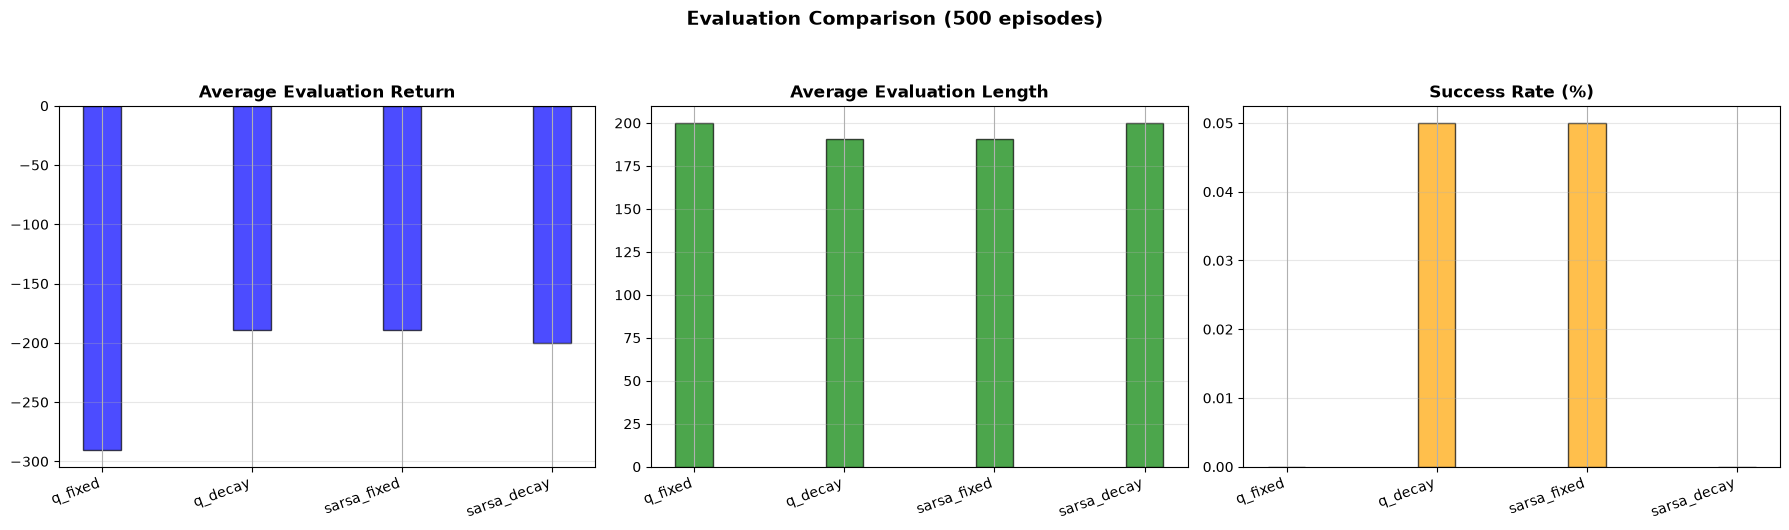

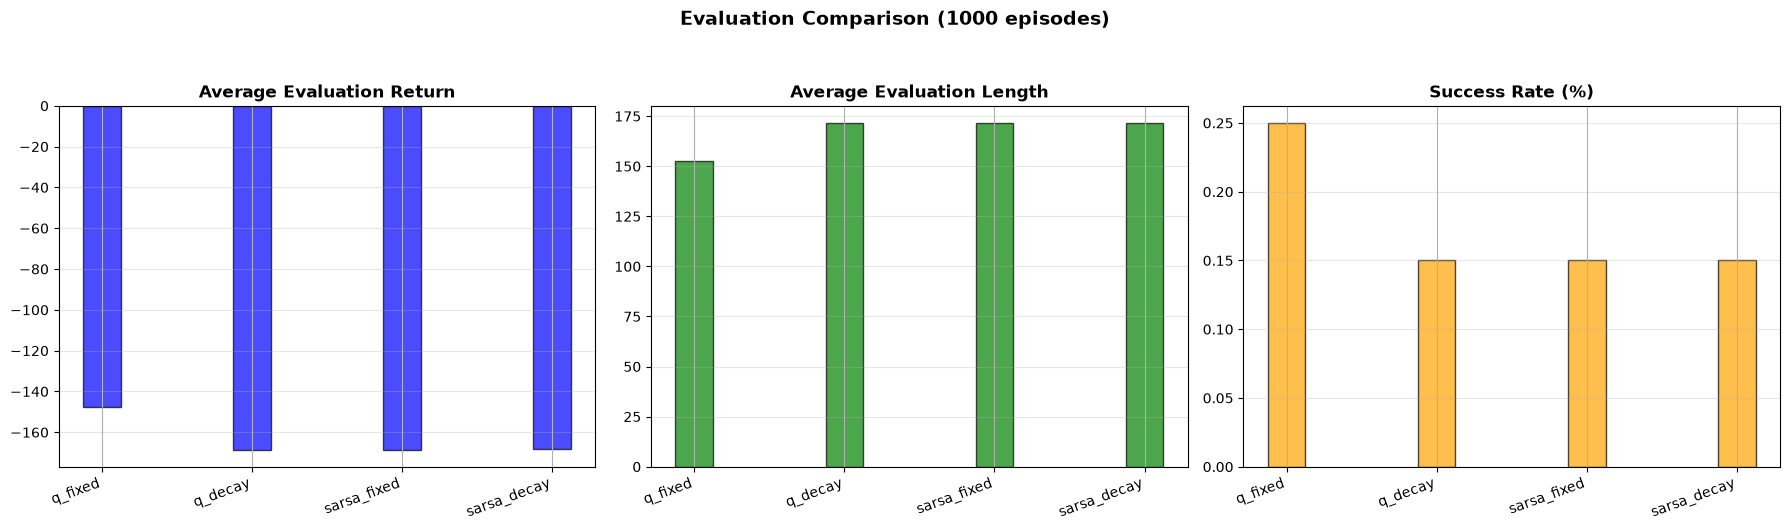

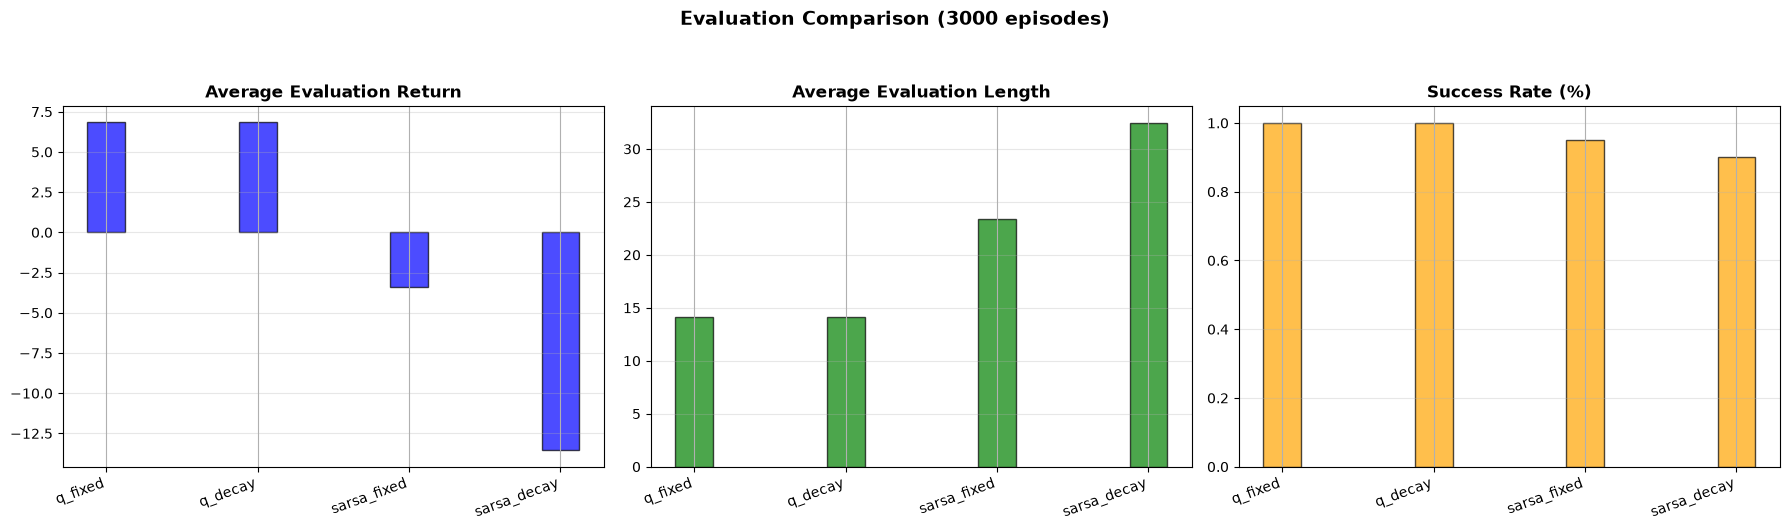

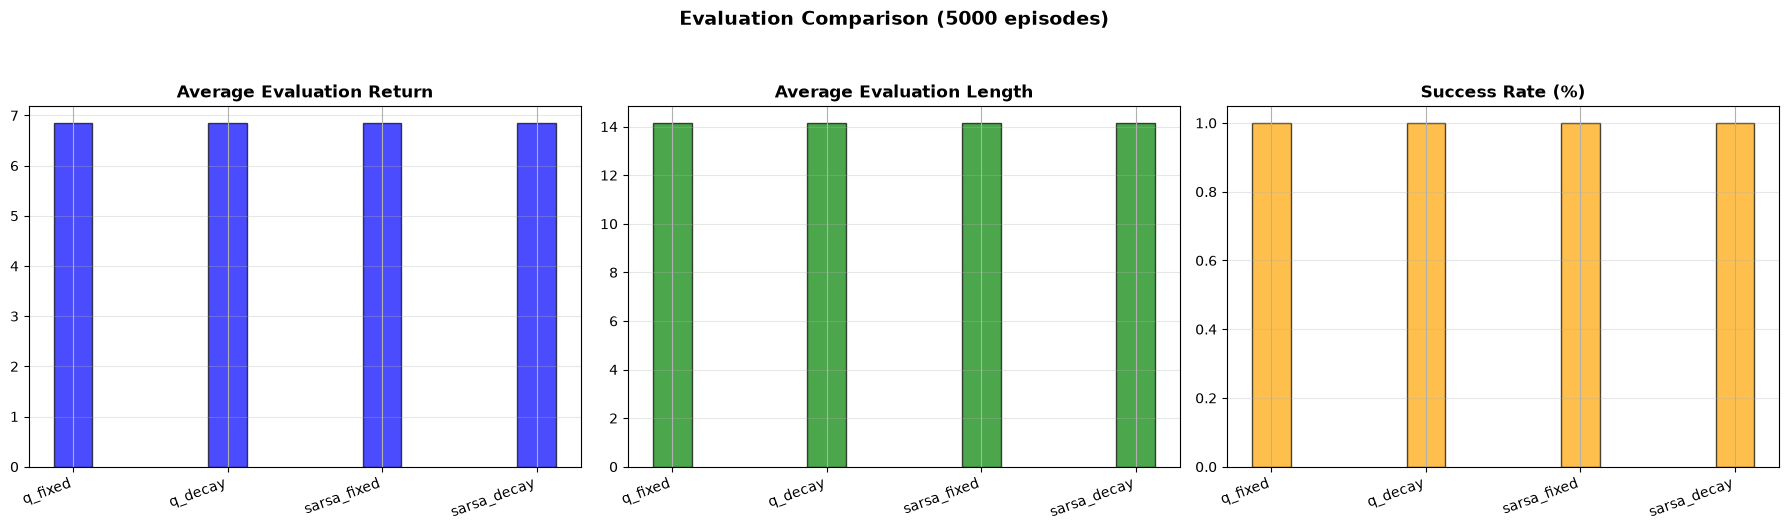

In [9]:
for episodes, results in all_results.items():
    eval_rows = []
    for name, res in results.items():
        metrics = evaluate_policy(res.q_table, episodes=20)
        eval_rows.append({
            "setting": name,
            "avg_eval_return": metrics["avg_return"],
            "avg_eval_length": metrics["avg_length"],
            "success_rate": metrics["success_rate"],
        })
    
    summary_df = pd.DataFrame(eval_rows)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    width = 0.25
    x = np.arange(len(summary_df))

    # Plot 1: Average Evaluation Return
    axes[0].bar(x, summary_df["avg_eval_return"], width, color='blue', alpha=0.7, edgecolor='black')
    axes[0].set_title("Average Evaluation Return", fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(summary_df["setting"], rotation=20, ha="right")
    axes[0].grid(axis='y', alpha=0.3)

    # Plot 2: Average Evaluation Length
    axes[1].bar(x, summary_df["avg_eval_length"], width, color='green', alpha=0.7, edgecolor='black')
    axes[1].set_title("Average Evaluation Length", fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(summary_df["setting"], rotation=20, ha="right")
    axes[1].grid(axis='y', alpha=0.3)

    # Plot 3: Success Rate
    axes[2].bar(x, summary_df["success_rate"], width, color='orange', alpha=0.7, edgecolor='black')
    axes[2].set_title("Success Rate (%)", fontweight='bold')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(summary_df["setting"], rotation=20, ha="right")
    axes[2].grid(axis='y', alpha=0.3)

    plt.suptitle(f'Evaluation Comparison ({episodes} episodes)', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

## Agent Demonstration

Animations showing three trained agents solving the Taxi problem.

In [ ]:
#خروجی های انیمیشن این سلول رو بخاطر حجم زیاد پاک کردم
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def run_greedy_episode_animation(q_table, env_id="Taxi-v3"):
    """Run a greedy episode and create an animation for Taxi"""
    env = gym.make(env_id, render_mode='rgb_array')
    state, _ = env.reset(seed=SEED)
    done = False
    total_reward = 0.0
    steps = 0
    
    frames = []
    
    while not done:
        action = int(np.argmax(q_table[state]))
        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1
        done = terminated or truncated
        
        frame = env.render()
        frames.append(frame)
    
    env.close()
    
    # Create animation
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.axis('off')
    
    def animate(i):
        ax.clear()
        ax.imshow(frames[i])
        ax.axis('off')
        
        status = ""
        if i == len(frames)-1 and total_reward > 0:
            status = "\n✅ Passenger delivered!"
        
        ax.set_title(f'Taxi - Step {i+1}/{steps}\n'
                    f'Total Reward: {total_reward}'
                    f'{status}', 
                    fontsize=12)
    
    anim = FuncAnimation(fig, animate, frames=len(frames), interval=200)
    plt.close()
    
    return anim, steps, total_reward

# Show 3 examples: Good, Medium, Bad
# Pick agents from results_500 (worst), results_5000 (medium), results_10000 (best)
agents_to_show = {
    "10000 ep - q_decay": results_5000["q_decay"].q_table,
    "5000 ep - sarsa_decay": results_1000["sarsa_decay"].q_table,
    "500 ep - q_fixe)": results_500["q_fixed"].q_table
}

for name, q_table in agents_to_show.items():
    print(f"\nAgent: {name}")
    anim, steps, total_reward = run_greedy_episode_animation(q_table)
    print(f"Steps: {steps}, Reward: {total_reward}")
    display(HTML(anim.to_jshtml()))
    time.sleep(1)

## Questions

### Question 1
Compare Q-Learning and SARSA performance. Which algorithm achieved better success rates and why? Consider their off-policy vs. on-policy nature in your explanation.

**Your answer:**الگوریتم SARSA معمولاً در حین آموزش و در حضور سیاست‌های تصادفی با نرخ ثابت به دلیل On-policy بودن عملکرد امن‌تری دارد و سریع‌تر به یک سیاست پایدارتر می‌رسد. SARSA در زمان آپدیت مقدار Q، عمل بعدی را در نظر می‌گیرد. اما Q-Learning به دلیل Off-policy بودن، همیشه با فرض انتخاب بهترین عمل مقادیر را آپدیت می‌کند. این ویژگی باعث می‌شود Q-Learning مسیرهای بهینه‌تر اما خطرناک‌تری را یاد بگیرد که اگر نرخ Exploration (مثل حالت Fixed) کاهش نیابد، جریمه‌های زیادی در حین یادگیری برایش به همراه خواهد داشت.



### Question 2
Compare fixed epsilon-greedy vs. decaying epsilon-greedy. Which strategy worked better and why? What is the trade-off between exploration and exploitation in each approach?

**Your answer:**استراتژی Decaying Epsilon-Greedy بسیار بهتر عمل کرد.

در استراتژی Fixed Epsilon-Greedy، ایجنت حتی زمانی که محیط را کاملاً شناخته، همچنان با احتمال ثابت epsilon کارهای تصادفی انجام می‌دهد که منجر به جریمه‌های بی‌دلیل  می‌شود

اما در استراتژی Decaying، ما به یک تعادل ایده‌آل بین Exploration و Exploitation می‌رسیم. در ابتدای آموزش، ایجنت با نرخ بالای epsilon در محیط می‌گردد تا حالات مختلف را کشف کند و با گذشت اپیزودها، epsilon کاهش می‌یابد تا ایجنت بر اساس دانش به دست آمده بهترین اعمال را به صورت حریصانه انتخاب کند


### Question 3
Based on your results, which combination of algorithm and exploration strategy would you recommend for the Taxi problem? Justify your choice using evidence from your training curves and evaluation metrics.

**Your answer:**ترکیب Q-Learning همراه با استراتژی Decaying Epsilon-Greedy بهترین انتخاب است.

چون Q-Learning مستقیماً مقادیر بهینه  را یاد می‌گیرد (به کمک عملگر max) و استفاده از Decaying Epsilon-Greedy به آن اجازه می‌دهد تا در اپیزودهای اولیه به اندازه کافی در محیط بگردد و در نهایت با رسیدن epsilon به حداقل ممکن، از رفتارهای تصادفیِ مخرب دست بکشد. این ترکیب در پلات‌ها، بالاترین میانگین پاداش کوتاه‌ترین طول اپیزود و نرخ موفقیت ۱۰۰ درصدی را در زمان ارزیابی به ثبت می‌رساند.